In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch
print(torch.__version__)  # Verify PyTorch version
print(torch.cuda.is_available())  # Check if CUDA is available
print(torch.cuda.get_device_name(0))  # Get the name of your GPU (if available)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model(model, test_loader,class_names):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Store the predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate classification report
    report = classification_report(all_labels, all_preds, target_names=["PASS", "FAIL"])
    print("Classification Report:\n", report)

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)

    # Plot confusion matrix with true labels on x-axis
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["PASS", "FAIL"], yticklabels=["PASS", "FAIL"], cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("True Label")  # True labels on x-axis
    plt.ylabel("Predicted Label")  # Predicted labels on y-axis
    plt.show()

class ModifiedResNet(nn.Module):
    def __init__(self, original_model, hidden_units=512, dropout_prob=0.5):
        super(ModifiedResNet, self).__init__()
        self.base_model = original_model
        self.base_model.fc = nn.Identity()  # Remove the original fully connected layer
        
        # New fully connected layers
        self.fc1 = nn.Linear(2048, hidden_units)  # First hidden layer
        self.batch_norm1 = nn.BatchNorm1d(hidden_units)  # Batch normalization
        self.dropout = nn.Dropout(p=dropout_prob)  # Dropout layer
        self.fc2 = nn.Linear(hidden_units, 2)  # Output layer (2 classes)

    def forward(self, x):
        x = self.base_model(x)  # Extract features from ResNet
        
        # First hidden layer
        x = self.fc1(x)  # Pass through first hidden layer
        x = self.batch_norm1(x)  # Apply batch normalization
        x = torch.relu(x)  # Apply activation function (ReLU)
        x = self.dropout(x)  # Apply dropout
        
        # Output layer
        x = self.fc2(x)  # Pass through the final output layer
        return x

# Function to load the model from the saved file and evaluate it
def load_and_evaluate_model(save_path, test_loader, class_names):
    # Reinitialize the model architecture
    model = ModifiedResNet(models.resnet50(pretrained=False))  # Make sure to set pretrained=False
    model.load_state_dict(torch.load(save_path))  # Load the saved model weights

    # Move the model to the appropriate device (GPU/CPU)
    model = model.to(device)
    
    # Set the model to evaluation mode and evaluate on the test set
    evaluate_model(model, test_loader, class_names)


# Data transformations (resizing, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize based on ImageNet
])

# Dataset directories
train_dir = f'img_is2_{v}/train'
test_dir = f'img_is2_{v}/test'
val_dir = f'img_is2_{v}/validate'
batch_size = 8  # Set the batch size

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# In the main section, load the model and evaluate it on the test set
if __name__ == "__main__":
    # Class names (replace with your actual class names)
    class_names = train_dataset.classes  # Assuming the ImageFolder provides the class names

    # Load the saved model and evaluate on the test set
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    save_path = f'best_model_IS2_{v}.pth'
    load_and_evaluate_model(save_path, test_loader, class_names)


device(type='cuda')

C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\4082745238.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))  # Load th

Classification Report:
               precision    recall  f1-score   support

        PASS       0.67      0.63      0.65       737
        FAIL       0.65      0.69      0.67       740

    accuracy                           0.66      1477
   macro avg       0.66      0.66      0.66      1477
weighted avg       0.66      0.66      0.66      1477

Confusion Matrix:
 [[466 271]
 [229 511]]


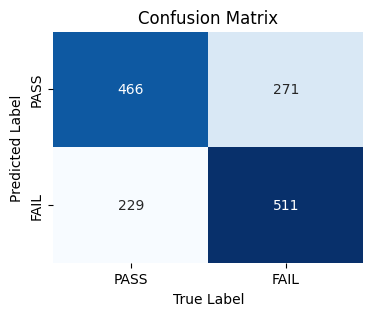

In [13]:
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms, datasets, models
from tqdm import tqdm
from torch.utils.data import DataLoader

# Data transformations (resizing, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize based on ImageNet
])
v='v2'
# Dataset directories
train_dir = f'img_is2_{v}/train'
test_dir = f'img_is2_{v}/test'
val_dir = f'img_is2_{v}/validate'

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 8  # Set the batch size

class ModifiedResNet(nn.Module):
    def __init__(self, original_model, hidden_units=512, dropout_prob=0.5):
        super(ModifiedResNet, self).__init__()
        self.base_model = original_model
        self.base_model.fc = nn.Identity()  # Remove the original fully connected layer
        
        # New fully connected layers
        self.fc1 = nn.Linear(2048, hidden_units)  # First hidden layer
        self.batch_norm1 = nn.BatchNorm1d(hidden_units)  # Batch normalization
        self.dropout = nn.Dropout(p=dropout_prob)  # Dropout layer
        self.fc2 = nn.Linear(hidden_units, 2)  # Output layer (2 classes)

    def forward(self, x):
        x = self.base_model(x)  # Extract features from ResNet
        
        # First hidden layer
        x = self.fc1(x)  # Pass through first hidden layer
        x = self.batch_norm1(x)  # Apply batch normalization
        x = torch.relu(x)  # Apply activation function (ReLU)
        x = self.dropout(x)  # Apply dropout
        
        # Output layer
        x = self.fc2(x)  # Pass through the final output layer
        return x

# Load pre-trained ResNet model
resnet = models.resnet50(pretrained=True)

# Initialize the modified model
model = ModifiedResNet(resnet, hidden_units=512, dropout_prob=0.7)

# Move model to the device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Learning Rate Scheduler: ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Mixed Precision Training (if GPU supports it)
scaler = torch.cuda.amp.GradScaler()

# Training and validation function
def train_validate_model(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler, num_epochs=50, patience=5, save_path="best_model.pth"):
    best_loss = float('inf')  # Initialize best validation loss
    patience_counter = 0      # Counter to track epochs without improvement

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Training Phase
        model.train()  # Set model to training mode
        with tqdm(total=len(train_loader), desc=f'Training Epoch [{epoch + 1}/{num_epochs}]', unit='batch') as pbar:
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)  # Move to device

                # Mixed precision forward pass
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                optimizer.zero_grad()

                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                # Track loss and accuracy
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Update progress bar
                pbar.set_postfix(loss=loss.item(), accuracy=correct / total)
                pbar.update(1)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = correct / total
        print(f'Epoch [{epoch + 1}/{num_epochs}] Training Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}')

        # Validation Phase
        val_loss, val_accuracy = validate_model(model, val_loader, criterion)
        print(f'Epoch [{epoch + 1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

        # Learning rate scheduling
        scheduler.step(val_loss)  # Adjust learning rate based on validation loss

        # Early stopping and save the best model
        if val_loss < best_loss:
            best_loss = val_loss  # Update best loss
            patience_counter = 0  # Reset patience counter if improvement
            torch.save(model.state_dict(), save_path)  # Save the best model
            print(f"Best model saved at epoch {epoch + 1}")
        else:
            patience_counter += 1  # Increment counter if no improvement
        
        # Stop training if patience is exceeded
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs. Validation loss did not improve for {patience} consecutive epochs.")
            break

        # Test the model on the test set after every epoch
        test_loss, test_accuracy = test_model(model, test_loader)
        print(f'Epoch [{epoch + 1}/{num_epochs}] Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

    # Load the best model for testing after training completes
    model.load_state_dict(torch.load(save_path))
    print("Best model loaded for testing.")
    return model

# Validation function
def validate_model(model, val_loader, criterion):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move to device

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct / total
    return val_loss, val_accuracy

# Test function for computing loss and accuracy on test set after every epoch
def test_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move to device
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_accuracy = correct / total
    return test_loss, test_accuracy

# Main script
if __name__ == "__main__":

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Set maximum number of epochs and patience for early stopping
    num_epochs = 200
    patience = 10
    save_path = f'best_model_IS2_{v}.pth'  # Path to save the best model

    # Train and validate the model with early stopping and best model saving
    best_model = train_validate_model(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler, num_epochs, patience, save_path)

    # After training, evaluate the best model on the test set
    test_loss, test_accuracy = test_model(best_model, test_loader)
    print(f'Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_accuracy:.4f}')


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\3752235389.py:7

cuda


Training Epoch [1/200]:   0%|          | 0/1107 [00:00<?, ?batch/s]C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\3752235389.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training Epoch [1/200]: 100%|██████████| 1107/1107 [02:14<00:00,  8.23batch/s, accuracy=0.6, loss=0.916]  


Epoch [1/200] Training Loss: 0.6946, Accuracy: 0.6000
Epoch [1/200] Validation Loss: 0.6002, Validation Accuracy: 0.6667
Best model saved at epoch 1
Epoch [1/200] Test Loss: 0.6099, Test Accuracy: 0.6567


Training Epoch [2/200]: 100%|██████████| 1107/1107 [01:00<00:00, 18.23batch/s, accuracy=0.625, loss=0.561]


...

Epoch [14/200] Training Loss: 0.1725, Accuracy: 0.9395
Epoch [14/200] Validation Loss: 0.8908, Validation Accuracy: 0.6673
Epoch [14/200] Test Loss: 0.9310, Test Accuracy: 0.6845


Training Epoch [15/200]: 100%|██████████| 1107/1107 [01:09<00:00, 16.01batch/s, accuracy=0.955, loss=0.0184] 


Epoch [15/200] Training Loss: 0.1346, Accuracy: 0.9553
Epoch [15/200] Validation Loss: 0.8849, Validation Accuracy: 0.6951
Early stopping triggered after 15 epochs. Validation loss did not improve for 10 consecutive epochs.
Best model loaded for testing.


C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\3752235389.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Final Test Loss: 0.5617, Final Test Accuracy: 0.7089


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\1021281425.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allo

Total number of trainable parameters: 24559170


C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\4082745238.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))  # Load th

Classification Report:
               precision    recall  f1-score   support

        PASS       0.73      0.66      0.70       737
        FAIL       0.69      0.75      0.72       740

    accuracy                           0.71      1477
   macro avg       0.71      0.71      0.71      1477
weighted avg       0.71      0.71      0.71      1477

Confusion Matrix:
 [[490 247]
 [183 557]]


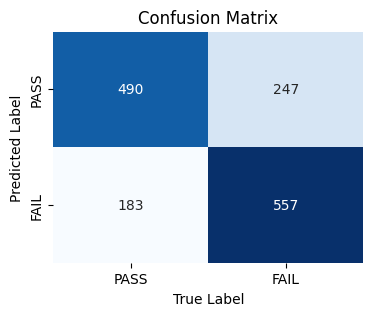

In [14]:
model = ModifiedResNet(models.resnet50(pretrained=False))  # Make sure to set pretrained=False
model.load_state_dict(torch.load(save_path))  # Load the saved model weights
import torch
import torchvision.models as models

# Assuming you have already defined ModifiedResNet and instantiated your model
model = ModifiedResNet(models.resnet50(pretrained=False))  # Make sure to set pretrained=False
model.load_state_dict(torch.load(save_path))  # Load the saved model weights

# Function to count total parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count and print the number of parameters
num_params = count_parameters(model)
print(f'Total number of trainable parameters: {num_params}')

# Data transformations (resizing, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize based on ImageNet
])

# Dataset directories
train_dir = f'img_is2_{v}/train'
test_dir = f'img_is2_{v}/test'
val_dir = f'img_is2_{v}/validate'
batch_size = 8  # Set the batch size

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# In the main section, load the model and evaluate it on the test set
if __name__ == "__main__":
    # Class names (replace with your actual class names)
    class_names = train_dataset.classes  # Assuming the ImageFolder provides the class names

    # Load the saved model and evaluate on the test set
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    save_path = f'best_model_IS2_{v}.pth'
    load_and_evaluate_model(save_path, test_loader, class_names)


In [15]:
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms, datasets, models
from tqdm import tqdm
from torch.utils.data import DataLoader

# Data transformations (resizing, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize based on ImageNet
])
v='v3'
# Dataset directories
train_dir = f'img_is2_{v}/train'
test_dir = f'img_is2_{v}/test'
val_dir = f'img_is2_{v}/validate'

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 8  # Set the batch size

class ModifiedResNet(nn.Module):
    def __init__(self, original_model, hidden_units=512, dropout_prob=0.5):
        super(ModifiedResNet, self).__init__()
        self.base_model = original_model
        self.base_model.fc = nn.Identity()  # Remove the original fully connected layer
        
        # New fully connected layers
        self.fc1 = nn.Linear(2048, hidden_units)  # First hidden layer
        self.batch_norm1 = nn.BatchNorm1d(hidden_units)  # Batch normalization
        self.dropout = nn.Dropout(p=dropout_prob)  # Dropout layer
        self.fc2 = nn.Linear(hidden_units, 2)  # Output layer (2 classes)

    def forward(self, x):
        x = self.base_model(x)  # Extract features from ResNet
        
        # First hidden layer
        x = self.fc1(x)  # Pass through first hidden layer
        x = self.batch_norm1(x)  # Apply batch normalization
        x = torch.relu(x)  # Apply activation function (ReLU)
        x = self.dropout(x)  # Apply dropout
        
        # Output layer
        x = self.fc2(x)  # Pass through the final output layer
        return x

# Load pre-trained ResNet model
resnet = models.resnet50(pretrained=True)

# Initialize the modified model
model = ModifiedResNet(resnet, hidden_units=512, dropout_prob=0.7)

# Move model to the device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Learning Rate Scheduler: ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Mixed Precision Training (if GPU supports it)
scaler = torch.cuda.amp.GradScaler()

# Training and validation function
def train_validate_model(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler, num_epochs=50, patience=5, save_path="best_model.pth"):
    best_loss = float('inf')  # Initialize best validation loss
    patience_counter = 0      # Counter to track epochs without improvement

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Training Phase
        model.train()  # Set model to training mode
        with tqdm(total=len(train_loader), desc=f'Training Epoch [{epoch + 1}/{num_epochs}]', unit='batch') as pbar:
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)  # Move to device

                # Mixed precision forward pass
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                optimizer.zero_grad()

                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                # Track loss and accuracy
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Update progress bar
                pbar.set_postfix(loss=loss.item(), accuracy=correct / total)
                pbar.update(1)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = correct / total
        print(f'Epoch [{epoch + 1}/{num_epochs}] Training Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}')

        # Validation Phase
        val_loss, val_accuracy = validate_model(model, val_loader, criterion)
        print(f'Epoch [{epoch + 1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

        # Learning rate scheduling
        scheduler.step(val_loss)  # Adjust learning rate based on validation loss

        # Early stopping and save the best model
        if val_loss < best_loss:
            best_loss = val_loss  # Update best loss
            patience_counter = 0  # Reset patience counter if improvement
            torch.save(model.state_dict(), save_path)  # Save the best model
            print(f"Best model saved at epoch {epoch + 1}")
        else:
            patience_counter += 1  # Increment counter if no improvement
        
        # Stop training if patience is exceeded
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs. Validation loss did not improve for {patience} consecutive epochs.")
            break

        # Test the model on the test set after every epoch
        test_loss, test_accuracy = test_model(model, test_loader)
        print(f'Epoch [{epoch + 1}/{num_epochs}] Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

    # Load the best model for testing after training completes
    model.load_state_dict(torch.load(save_path))
    print("Best model loaded for testing.")
    return model

# Validation function
def validate_model(model, val_loader, criterion):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move to device

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct / total
    return val_loss, val_accuracy

# Test function for computing loss and accuracy on test set after every epoch
def test_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move to device
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_accuracy = correct / total
    return test_loss, test_accuracy

# Main script
if __name__ == "__main__":

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Set maximum number of epochs and patience for early stopping
    num_epochs = 200
    patience = 10
    save_path = f'best_model_IS2_{v}.pth'  # Path to save the best model

    # Train and validate the model with early stopping and best model saving
    best_model = train_validate_model(model, train_loader, val_loader, test_loader, criterion, optimizer, scheduler, num_epochs, patience, save_path)

    # After training, evaluate the best model on the test set
    test_loss, test_accuracy = test_model(best_model, test_loader)
    print(f'Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_accuracy:.4f}')


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\1016488896.py:7

cuda


Training Epoch [1/200]:   0%|          | 0/1107 [00:00<?, ?batch/s]C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\1016488896.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training Epoch [1/200]: 100%|██████████| 1107/1107 [02:24<00:00,  7.64batch/s, accuracy=0.598, loss=0.554]


Epoch [1/200] Training Loss: 0.7001, Accuracy: 0.5982
Epoch [1/200] Validation Loss: 0.5877, Validation Accuracy: 0.6626
Best model saved at epoch 1
Epoch [1/200] Test Loss: 0.6001, Test Accuracy: 0.6567


Training Epoch [2/200]: 100%|██████████| 1107/1107 [01:04<00:00, 17.20batch/s, accuracy=0.643, loss=0.432]


...

Epoch [13/200] Training Loss: 0.1387, Accuracy: 0.9537
Epoch [13/200] Validation Loss: 0.8397, Validation Accuracy: 0.6931
Epoch [13/200] Test Loss: 0.8499, Test Accuracy: 0.6926


Training Epoch [14/200]: 100%|██████████| 1107/1107 [01:33<00:00, 11.83batch/s, accuracy=0.969, loss=0.00706]


Epoch [14/200] Training Loss: 0.1005, Accuracy: 0.9694
Epoch [14/200] Validation Loss: 1.0207, Validation Accuracy: 0.7012
Early stopping triggered after 14 epochs. Validation loss did not improve for 10 consecutive epochs.


C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\1016488896.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Best model loaded for testing.
Final Test Loss: 0.5762, Final Test Accuracy: 0.6987


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\1021281425.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allo

Total number of trainable parameters: 24559170


C:\Users\1000305259\AppData\Local\Temp\ipykernel_11568\4082745238.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))  # Load th

Classification Report:
               precision    recall  f1-score   support

        PASS       0.73      0.63      0.68       737
        FAIL       0.67      0.77      0.72       740

    accuracy                           0.70      1477
   macro avg       0.70      0.70      0.70      1477
weighted avg       0.70      0.70      0.70      1477

Confusion Matrix:
 [[463 274]
 [171 569]]


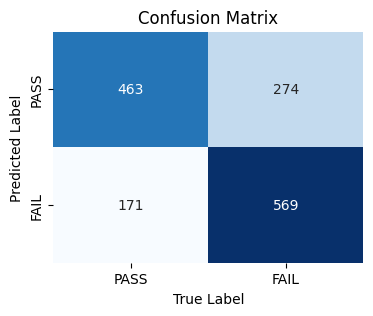

In [16]:
model = ModifiedResNet(models.resnet50(pretrained=False))  # Make sure to set pretrained=False
model.load_state_dict(torch.load(save_path))  # Load the saved model weights
import torch
import torchvision.models as models

# Assuming you have already defined ModifiedResNet and instantiated your model
model = ModifiedResNet(models.resnet50(pretrained=False))  # Make sure to set pretrained=False
model.load_state_dict(torch.load(save_path))  # Load the saved model weights

# Function to count total parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count and print the number of parameters
num_params = count_parameters(model)
print(f'Total number of trainable parameters: {num_params}')

# Data transformations (resizing, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize based on ImageNet
])

# Dataset directories
train_dir = f'img_is2_{v}/train'
test_dir = f'img_is2_{v}/test'
val_dir = f'img_is2_{v}/validate'
batch_size = 8  # Set the batch size

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# In the main section, load the model and evaluate it on the test set
if __name__ == "__main__":
    # Class names (replace with your actual class names)
    class_names = train_dataset.classes  # Assuming the ImageFolder provides the class names

    # Load the saved model and evaluate on the test set
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    save_path = f'best_model_IS2_{v}.pth'
    load_and_evaluate_model(save_path, test_loader, class_names)
